In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
getwd()

[1] "/Users/rob/Projects/R/ISLR2"

In [3]:
source("InstallAndLoadScripts/loadlibraries.R")

In [4]:
loadISLR2Libraries()

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The follow

In [5]:
getwd()

[1] "/Users/rob/Projects/R/ISLR2"

In [6]:
Greenhouses = read.csv("data/GreenhousesTraining.csv")

In [7]:
as_tibble(Greenhouses)[1:10,]

price,solarPanels,greenhouses,size,rowIndex,price.1
<int>,<dbl>,<dbl>,<int>,<int>,<dbl>
1500,5.0,2.5,430,0,1160.2158
2990,12.0,3.0,470,1,2613.8008
1990,8.0,3.0,315,3,1199.2451
1500,7.5,1.5,245,4,-204.8692
1300,16.0,1.5,290,7,1161.0151
7500,12.0,7.5,1035,8,8678.2586
1800,8.0,2.0,565,9,2017.4907
7600,20.0,6.0,770,10,7255.9013
1990,6.0,3.0,350,11,1140.7769


In [8]:
max(Greenhouses["price"] - Greenhouses["price.1"])

[1] 7320.52

In [9]:
RSS = sum((Greenhouses["price"] - Greenhouses["price.1"])^2)

In [10]:
print(RSS)

[1] 362962110


In [11]:
MSE = sqrt(RSS/316)

In [12]:
print(MSE)

[1] 1071.734


In [13]:
#cbPalette = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
#scale_colour_manual(values=cbPalette)

In [14]:
lm01 = lm(price ~ solarPanels + greenhouses + size, data=Greenhouses)
summary(lm01)


Call:
lm(formula = price ~ solarPanels + greenhouses + size, data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-2230.6  -681.5  -147.6   508.5  7392.2 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3450.6510   174.5540  -19.77   <2e-16 ***
solarPanels   131.6433    11.1679   11.79   <2e-16 ***
greenhouses   623.1585    47.3466   13.16   <2e-16 ***
size            5.6022     0.4609   12.15   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1071 on 316 degrees of freedom
Multiple R-squared:  0.8526,	Adjusted R-squared:  0.8512 
F-statistic: 609.2 on 3 and 316 DF,  p-value: < 2.2e-16


In [15]:
options(repr.plot.width = 15, repr.plot.height = 12)
f1 = ggplot(Greenhouses, aes(x=greenhouses, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ greenhouses") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

In [16]:
f2 = ggplot(Greenhouses, aes(x=solarPanels, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ solarPanels") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

In [17]:
f3 = ggplot(Greenhouses, aes(x=size, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ size") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


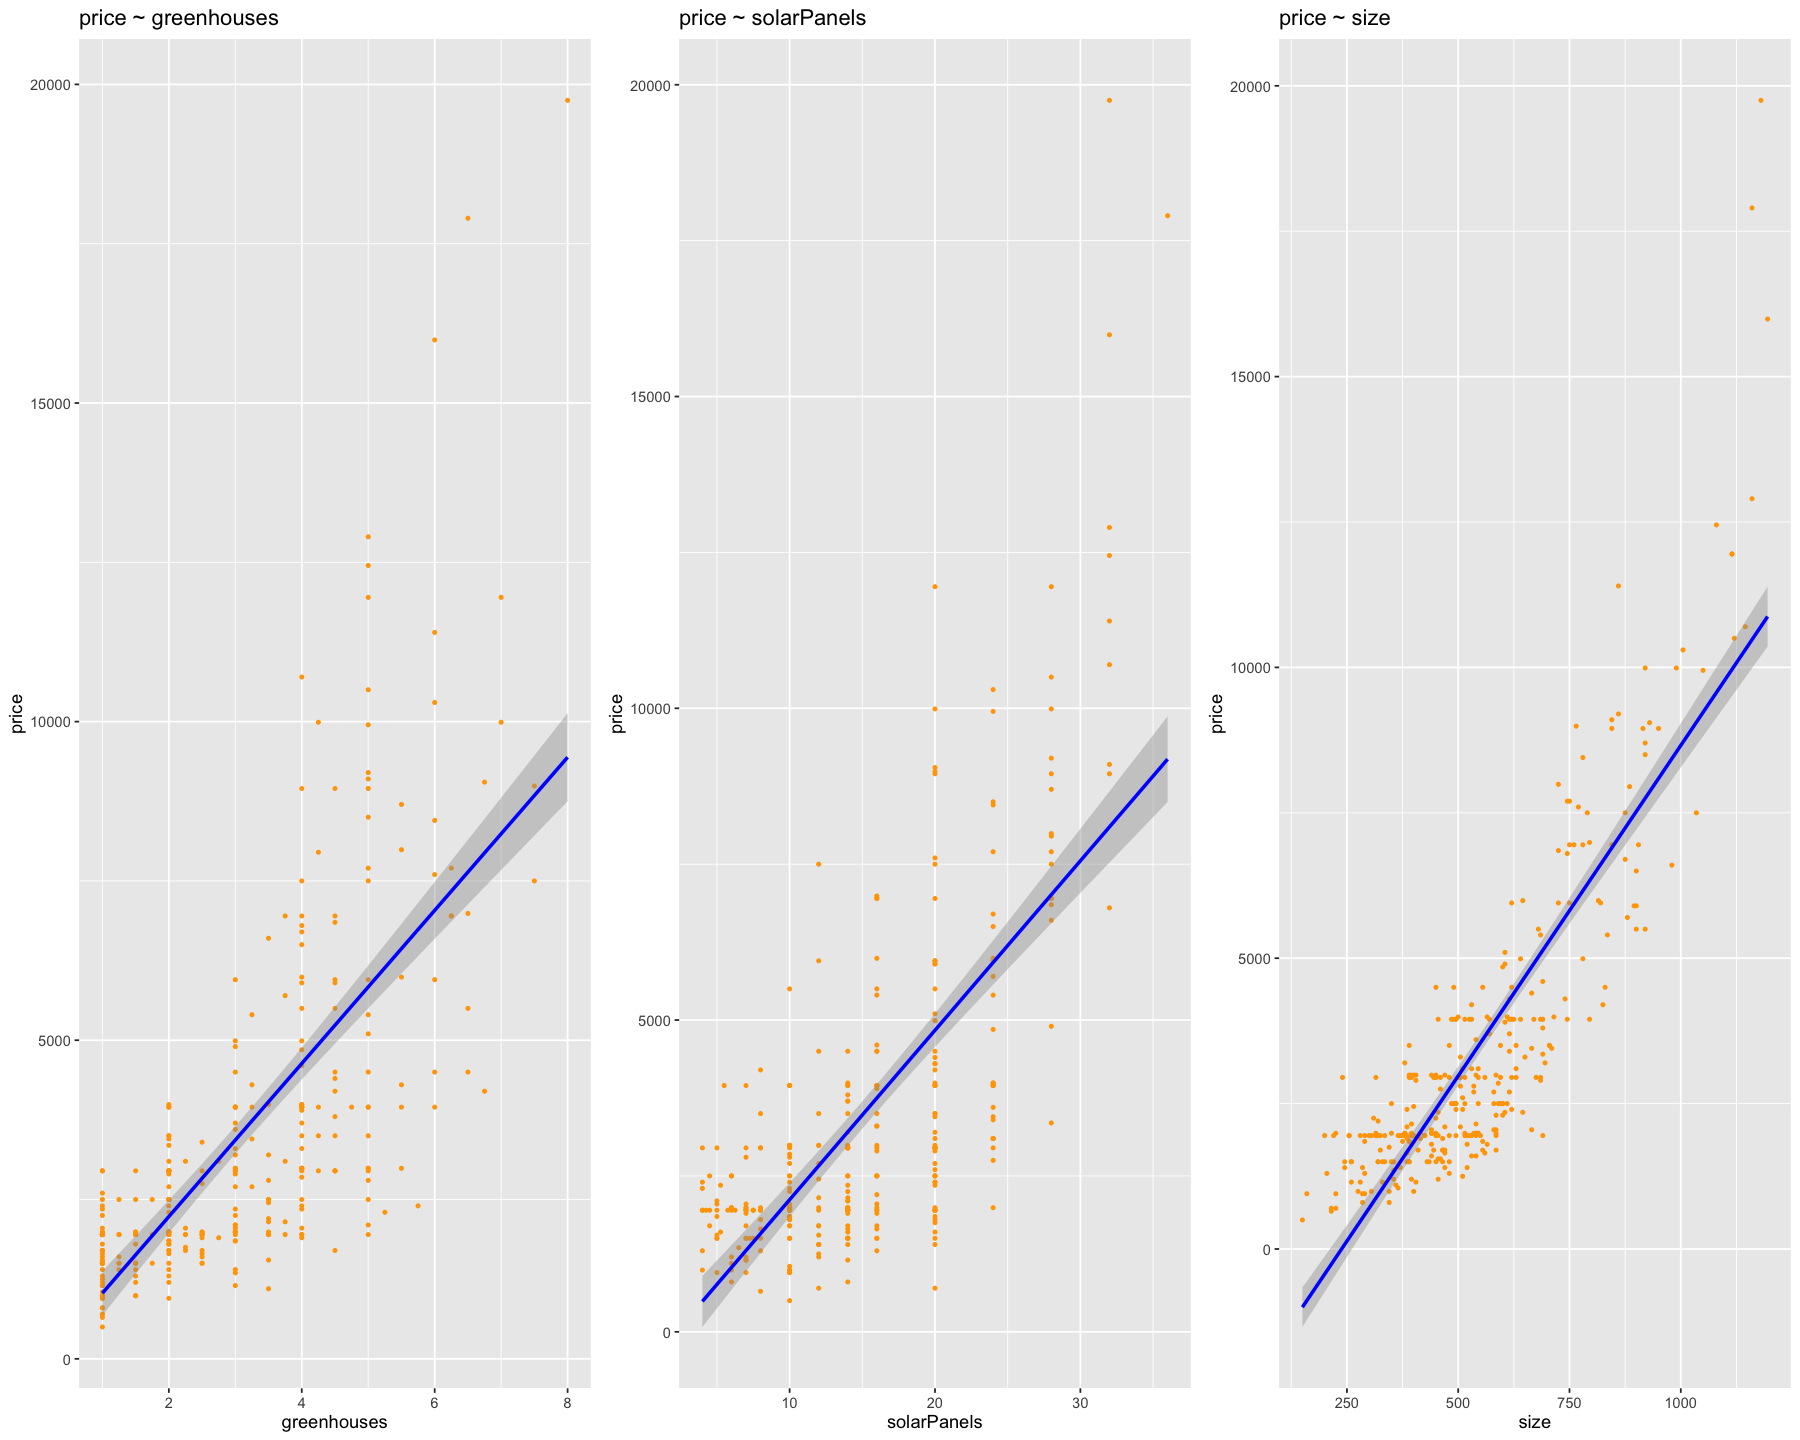

In [18]:
grid.arrange(f1, f2, f3, ncol = 3)

In [19]:
names(lm01)

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "xlevels"       "call"          "terms"         "model"

In [20]:
dim(Greenhouses)

[1] 320   6

In [21]:
residuals(lm01)[1:10]

1          2          3          4          5          6          7 
  325.6055   358.4366   753.3459  1656.0572    84.9918 -1101.0024  -214.0378 
         8          9         10 
  365.1641   820.5565   519.1691

In [22]:
RSS = sum(residuals(lm01)^2)

In [23]:
RSS

[1] 362654776

In [24]:
MSE = sqrt(RSS/316)

In [25]:
MSE

[1] 1071.28

In [26]:
mean_price = mean(Greenhouses$price)

In [27]:
mean_price

[1] 3503.625

In [28]:
TSS = sum((Greenhouses$price - mean_price)^2)

In [29]:
TSS

[1] 2460180195

In [30]:
R2 = 1 - RSS/TSS

In [31]:
R2

[1] 0.8525902

In [32]:
cor(Greenhouses$price, predict(lm01))^2

[1] 0.8525902

In [33]:
p = 3

In [34]:
n = 320

In [35]:
R_adj = 1 - ((1 - R2) * (n - 1) / (n - p - 1))

In [36]:
R_adj

[1] 0.8511907

In [37]:
F_stat = ((TSS-RSS)/p)/(RSS/(n-p-1))

In [38]:
F_stat

[1] 609.2277

In [39]:
p_value = pf(F_stat, p, n-p-1, lower.tail=FALSE)

In [40]:
p_value

[1] 5.566763e-131

In [41]:
str_interp("RSS = ${RSS}, MSE = ${MSE}, R2 = ${R2}, R_adj = ${R_adj}, F = ${F_stat}, 
           p = ${p_value}")

[1] "RSS = 362654776.429386, MSE = 1071.28040099749, R2 = 0.85259015694605, R_adj = 0.851190696410728, F = 609.227724131349, \n           p = 5.56676294842167e-131"

In [42]:
summary(lm01)


Call:
lm(formula = price ~ solarPanels + greenhouses + size, data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-2230.6  -681.5  -147.6   508.5  7392.2 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3450.6510   174.5540  -19.77   <2e-16 ***
solarPanels   131.6433    11.1679   11.79   <2e-16 ***
greenhouses   623.1585    47.3466   13.16   <2e-16 ***
size            5.6022     0.4609   12.15   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1071 on 316 degrees of freedom
Multiple R-squared:  0.8526,	Adjusted R-squared:  0.8512 
F-statistic: 609.2 on 3 and 316 DF,  p-value: < 2.2e-16


In [43]:
Greenhouses$pred = predict(lm01)

In [44]:
as_tibble(Greenhouses)[1:10,]

price,solarPanels,greenhouses,size,rowIndex,price.1,pred
<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
1500,5.0,2.5,430,0,1160.2158,1174.3945
2990,12.0,3.0,470,1,2613.8008,2631.5634
1990,8.0,3.0,315,3,1199.2451,1236.6541
1500,7.5,1.5,245,4,-204.8692,-156.0572
1300,16.0,1.5,290,7,1161.0151,1215.0082
7500,12.0,7.5,1035,8,8678.2586,8601.0024
1800,8.0,2.0,565,9,2017.4907,2014.0378
7600,20.0,6.0,770,10,7255.9013,7234.8359
1990,6.0,3.0,350,11,1140.7769,1169.4435


In [45]:
dim(Greenhouses)

[1] 320   7

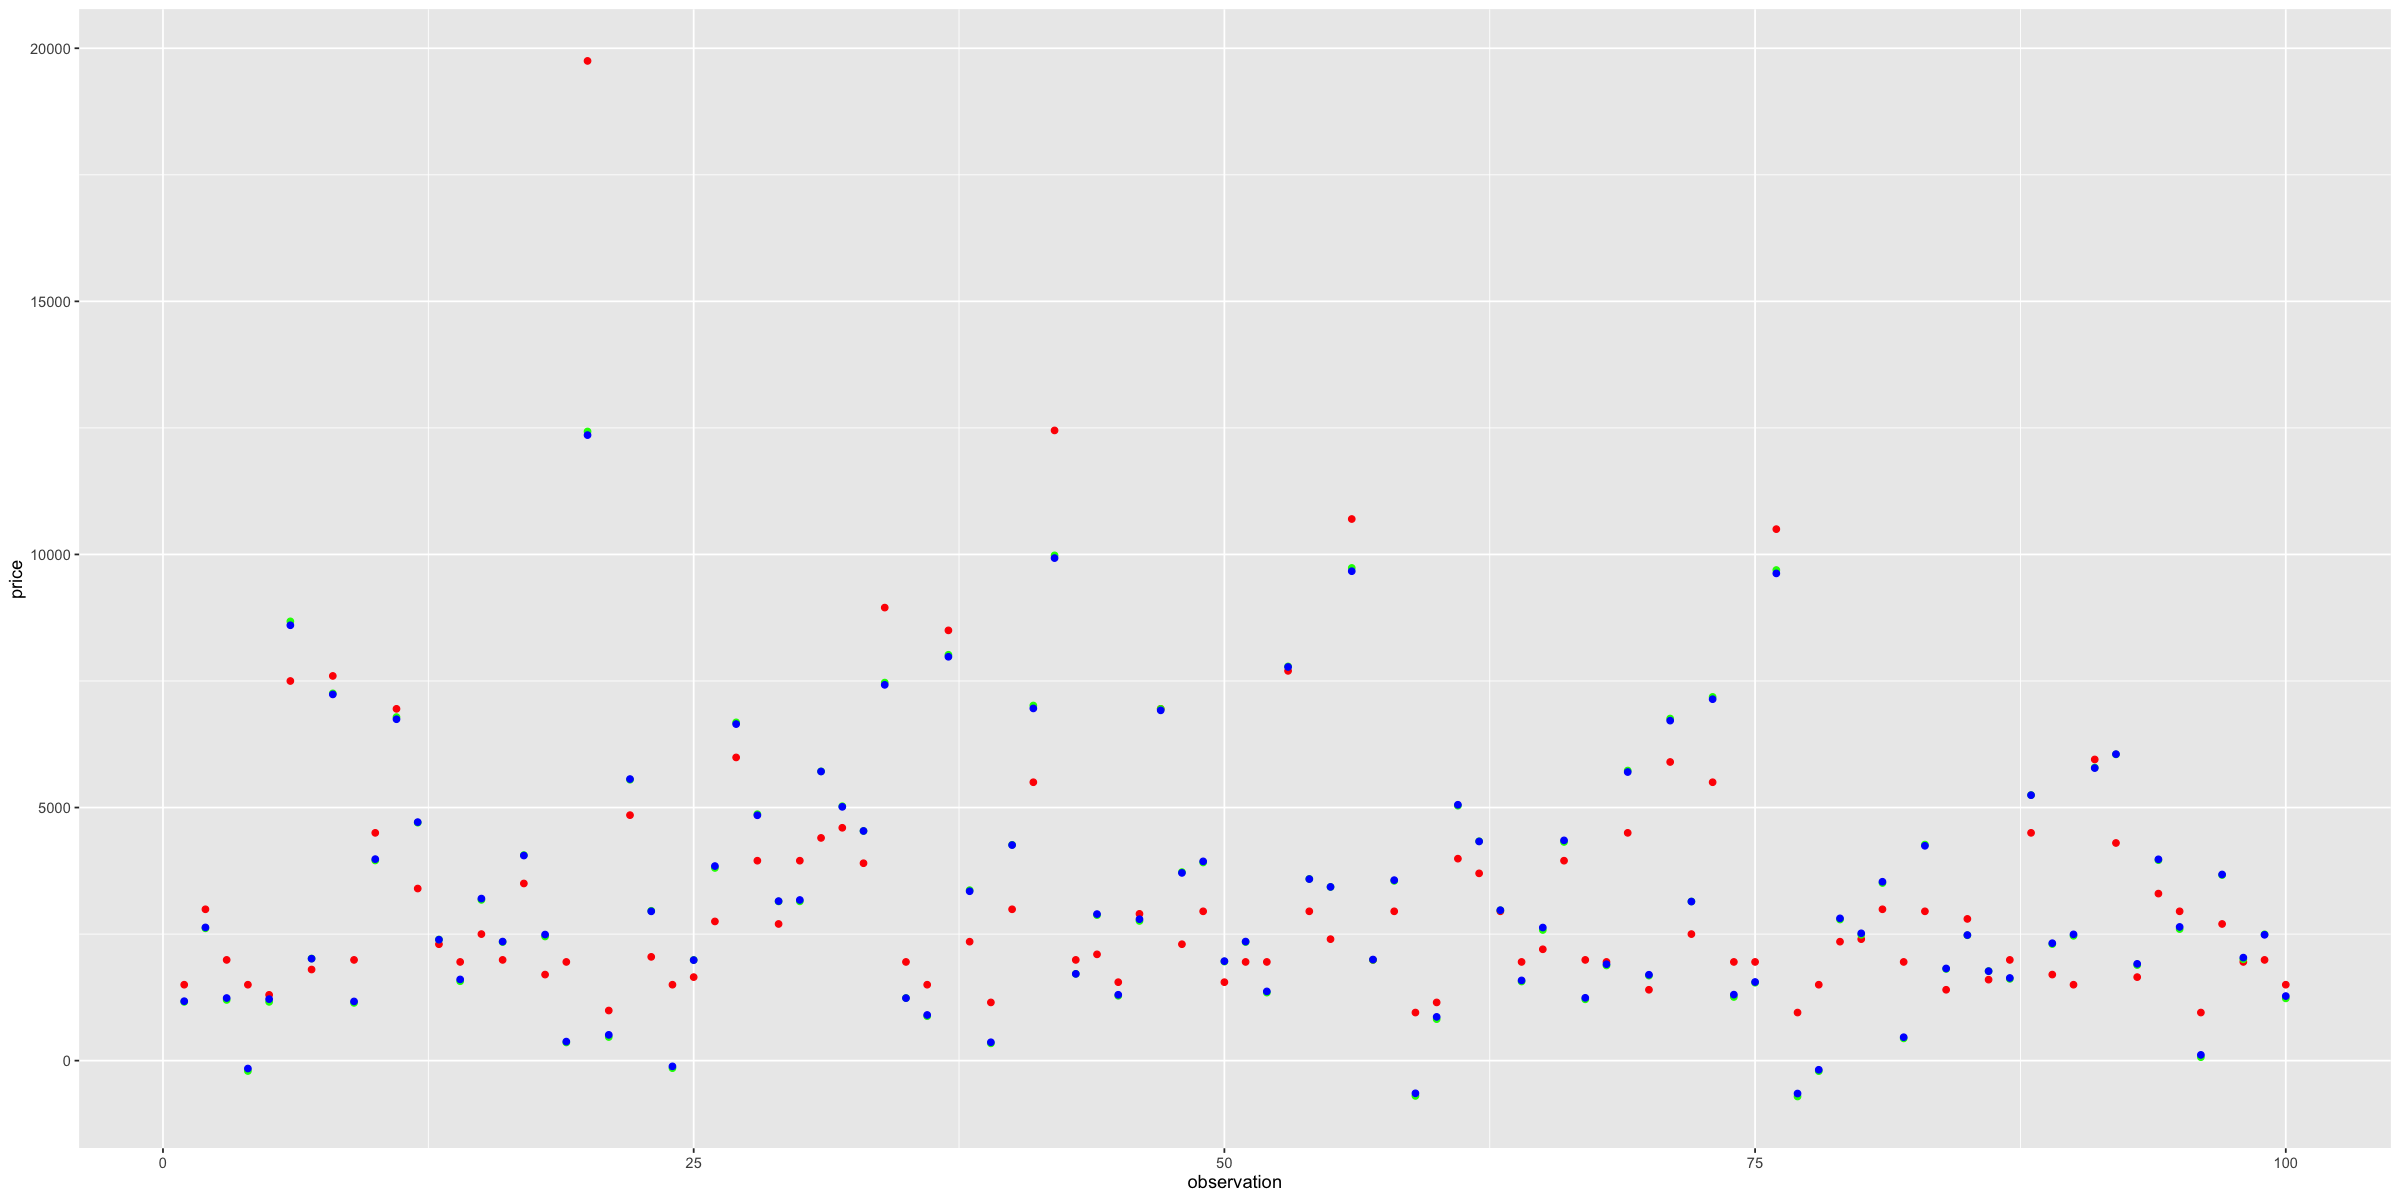

In [46]:
options(repr.plot.width = 20, repr.plot.height =10)
ggplot() + 
  geom_point(data = Greenhouses[1:100,], aes(x=1:100, y = price), color = "red") +
  geom_point(data = Greenhouses[1:100,], aes(x=1:100, y = price.1), color = "green") +
  geom_point(data = Greenhouses[1:100,], aes(x=1:100, y = pred), color = "blue") +
  xlab('observation') + ylab('price')